# ✅ Solutions — Module 13 — Time Series Analysis & Forecasting

Worked solutions for every exercise of this module. **Try the exercise yourself first** — you learn statistics by *doing* it. Each solution ends with a short interpretation, because in real projects the numbers are only half of the answer.

*Every exercise is self-contained: run the setup cell below, then jump to any exercise.*

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

### ✍️ Exercise 13.1 — *Smoothing*: What is the real trend in daily orders? (E-commerce operations)

An online shop's daily order counts show a strong weekly rhythm. Operations wants to know the underlying growth, the typical weekday pattern, and whether anything unusual happened.

**Tasks**
1. Plot the series with a centred 7-day moving average and an EWMA ($\alpha=0.1$). Why 7 days?
2. Estimate the **weekday pattern**: average ratio of orders to the 7-day moving average, by weekday.
3. Remove the weekday pattern (orders / weekday factor), estimate a **robust** baseline with a centred 29-day rolling *median*, and flag days whose ratio to that baseline deviates from 1 by more than 4 robust SDs.
4. Estimate the average growth in orders per month from the baseline.

In [2]:
g = np.random.default_rng(1301)
days = pd.date_range("2025-01-01", periods=240, freq="D")
base = (400 + .9 * np.arange(240)) * np.array([1.0, .95, .97, 1.02, 1.15, 1.35, 1.25])[days.dayofweek]
base[150:154] *= 1.8                                                       # something happened here …
orders = pd.Series(g.poisson(base), index=days, name="orders")
orders.head(8)

2025-01-01    368
2025-01-02    382
2025-01-03    486
2025-01-04    530
2025-01-05    491
2025-01-06    419
2025-01-07    397
2025-01-08    378
Freq: D, Name: orders, dtype: int64

weekday factors: {'Monday': 0.9, 'Tuesday': 0.87, 'Wednesday': 0.87, 'Thursday': 0.93, 'Friday': 1.04, 'Saturday': 1.24, 'Sunday': 1.14}

robust SD of the adjusted ratio: 0.041;  flagged days:
2025-05-31    1.79
2025-06-01    1.91
2025-06-02    1.81
2025-06-03    1.77
Freq: D, Name: orders, dtype: float64

growth ≈ 31 orders per day, per month


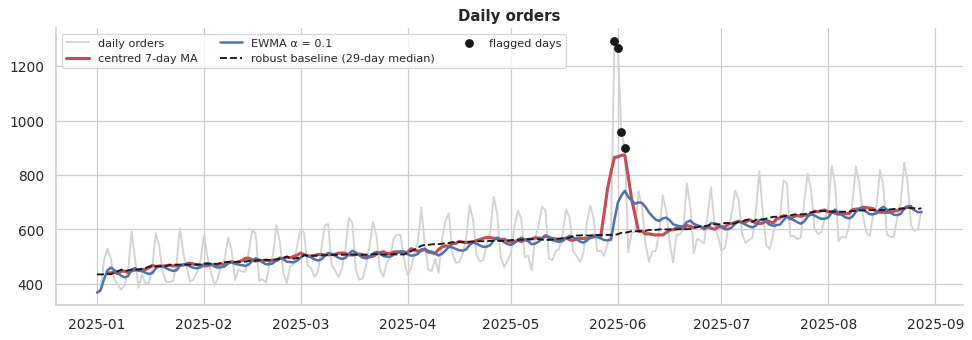

In [3]:
ma7 = orders.rolling(7, center=True).mean(); ew = orders.ewm(alpha=.1).mean()
weekday = (orders / ma7).groupby(orders.index.day_name()).median().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
print("weekday factors:", weekday.round(2).to_dict())
deseason = orders / orders.index.day_name().map(weekday).values                     # weekday pattern removed
baseline = deseason.rolling(29, center=True, min_periods=15).median()               # robust trend: a 4-day spike cannot move a 29-day median
adj = deseason / baseline
robust_sd = stats.median_abs_deviation(adj.dropna(), scale="normal"); flagged = adj[(adj - 1).abs() > 4 * robust_sd]
print(f"\nrobust SD of the adjusted ratio: {robust_sd:.3f};  flagged days:"); print(flagged.round(2))
slope = np.polyfit(np.arange(len(baseline)), baseline.values, 1)[0]; print(f"\ngrowth ≈ {slope * 30:.0f} orders per day, per month")
fig, ax = plt.subplots(figsize=(13, 4)); ax.plot(orders, color="lightgrey", label="daily orders"); ax.plot(ma7, color=C[3], lw=2.5, label="centred 7-day MA"); ax.plot(ew, color=C[0], lw=2, label="EWMA α = 0.1"); ax.plot(baseline, color="k", ls="--", lw=1.5, label="robust baseline (29-day median)")
ax.scatter(flagged.index, orders[flagged.index], color="k", zorder=3, label="flagged days"); ax.legend(ncol=3, fontsize=9); ax.set_title("Daily orders"); plt.show()

**Interpretation.** A window of exactly **7 days** contains every weekday once, so the weekly pattern cancels and only level and trend remain (a 5- or 10-day window would let part of the pattern leak through). The EWMA reacts to the weekly rhythm and lags behind — it is a monitoring tool, not a trend estimator for seasonal data.

The weekday factors show the business rhythm: Tuesday and Wednesday are the weakest days (≈ −13 % vs. the weekly average), Saturday the strongest (≈ +24 %). After removing the weekday effect and a robust trend, exactly four consecutive days (31 May – 3 June) stand out at roughly **+80 %** — a promotion, a press mention or a tracking error; a question for the business, not for statistics. Note *why* the baseline is a rolling **median**: the 7-day moving average is itself dragged upwards by the spike (look at the red line), and measured against it the normal days just before and after the event would be flagged as negative anomalies. Underlying growth is about **30 orders per day per month**.

**Lesson:** remove the known calendar structure *before* hunting for anomalies — otherwise every Saturday is an "outlier" — and use **robust** smoothers for the baseline, because means are contaminated by the very anomalies you are looking for.

### ✍️ Exercise 13.2 — *Decomposition*: Seasonally adjusting overnight stays (Tourism board)

A regional tourism board has ten years of monthly overnight stays (in thousands). The press office regularly compares "this month vs. last month", producing alarming headlines every autumn.

**Tasks**
1. Plot the series. Is the seasonality additive or multiplicative? Decide on a transformation.
2. Run an STL decomposition on the (transformed) series.
3. Convert the seasonal component into **seasonal factors** per calendar month (in %). Which months are peak and trough?
4. Compute the seasonally adjusted series and the average annual growth rate of the trend.
5. The latest November value is 20 % below October. What should the headline be?

In [4]:
g = np.random.default_rng(1302)
idx = pd.date_range("2015-01-01", periods=120, freq="MS"); t = np.arange(120)
season = 1 + .42 * np.cos(2 * np.pi * (idx.month - 8) / 12) + .15 * np.cos(4 * np.pi * (idx.month - 2) / 12)     # summer peak + small winter-sports bump
stays = pd.Series(80 * 1.04 ** (t / 12) * season * g.lognormal(0, .035, 120), index=idx, name="overnight_stays_k").round(1)
stays.tail(3)

2024-10-01    128.0
2024-11-01    102.3
2024-12-01     83.5
Freq: MS, Name: overnight_stays_k, dtype: float64

seasonal factors (% vs. trend): {1: -26, 2: -23, 3: -26, 4: -24, 5: -11, 6: 20, 7: 49, 8: 64, 9: 50, 10: 17, 11: -10, 12: -24}

average growth of the trend: +3.4% per year
Oct -> Nov 2024: raw -20.1%,  seasonally adjusted +1.2%


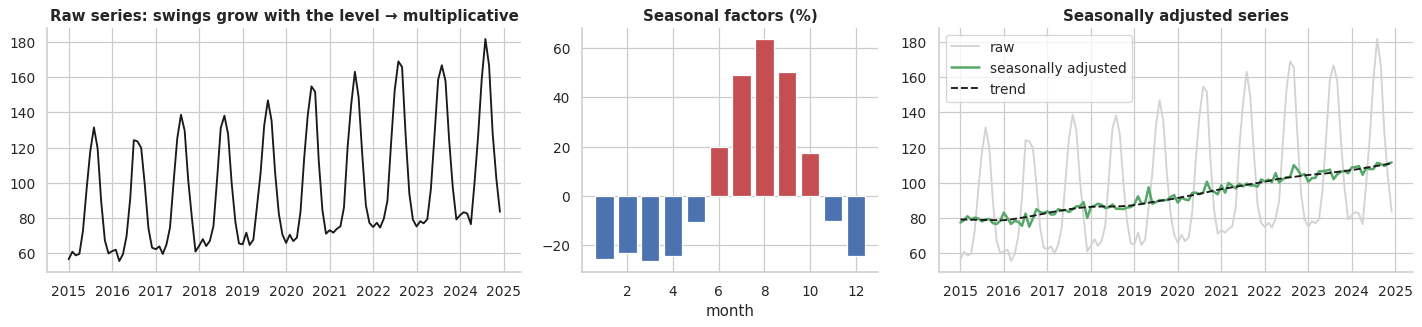

In [5]:
stl = STL(np.log(stays), period=12, robust=True).fit()
factors = (np.exp(stl.seasonal.groupby(stl.seasonal.index.month).mean()) - 1) * 100
adjusted = np.exp(np.log(stays) - stl.seasonal); growth = np.exp((stl.trend.iloc[-1] - stl.trend.iloc[0]) / (len(stays) / 12)) - 1
print("seasonal factors (% vs. trend):", factors.round(0).astype(int).to_dict())
print(f"\naverage growth of the trend: {growth:+.1%} per year")
print(f"Oct -> Nov 2024: raw {stays.iloc[-2] / stays.iloc[-3] - 1:+.1%},  seasonally adjusted {adjusted.iloc[-2] / adjusted.iloc[-3] - 1:+.1%}")
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8), gridspec_kw={"width_ratios": [1.6, 1, 1.6]})
axes[0].plot(stays, color="k"); axes[0].set_title("Raw series: swings grow with the level → multiplicative")
axes[1].bar(factors.index, factors.values, color=[C[3] if v > 0 else C[0] for v in factors.values]); axes[1].set(title="Seasonal factors (%)", xlabel="month")
axes[2].plot(stays, color="lightgrey", label="raw"); axes[2].plot(adjusted, color=C[2], lw=2, label="seasonally adjusted"); axes[2].plot(np.exp(stl.trend), color="k", ls="--", label="trend"); axes[2].legend(); axes[2].set_title("Seasonally adjusted series")
plt.tight_layout(); plt.show()

**Interpretation.** The seasonal swings grow with the level of the series → **multiplicative** seasonality → decompose the **log** series; exponentiating the seasonal component gives factors in percent. August is the peak (roughly +65 % above trend, with July and September around +50 %); from December to April the region runs about 25 % below trend, with only a faint winter-sports bump in February.

The trend grows by about **3.5 % per year**. The dramatic "−20 % from October to November" is entirely the normal seasonal pattern: seasonally adjusted, November is even slightly *up* (≈ +1 %).

**Headline:** not "Tourism collapses in November" but "Overnight stays on trend: +3.5 % per year after seasonal adjustment". **Lesson:** month-on-month comparisons of seasonal data are meaningless without adjustment; compare with the same month of the previous year, or better, use the adjusted series.

### ✍️ Exercise 13.3 — *Stationarity & spurious regression*: Do these two share prices move together? (Finance)

An analyst shows you three years of daily prices of two companies from unrelated industries and a regression with $R^2\approx0.65$ and a t-statistic beyond 30: "clearly these stocks are linked — we can hedge one with the other."

**Tasks**
1. Regress price A on price B. Report $R^2$, the t-statistic and the **Durbin–Watson** statistic of the residuals.
2. Run ADF tests on both price series and on their daily log-returns.
3. Regress the returns of A on the returns of B. What remains of the relationship?
4. Explain to the analyst what went wrong.

In [6]:
g = np.random.default_rng(1311)
n = 750; dates = pd.bdate_range("2023-01-02", periods=n)
prices = pd.DataFrame({"A": 100 * np.exp(np.cumsum(g.normal(.0004, .012, n))), "B": 50 * np.exp(np.cumsum(g.normal(.0003, .015, n)))}, index=dates).round(2)
prices.tail(3)

,A,B
2025-11-12,185.75,83.75
2025-11-13,186.87,85.95
2025-11-14,188.79,89.52


LEVELS : R² = 0.645, t = 36.8, p = 2.8e-170, Durbin–Watson = 0.028
RETURNS: R² = 0.0001, t = -0.32, p = 0.749, Durbin–Watson = 2.009

ADF price A  : p = 0.3191
ADF price B  : p = 0.1356
ADF return A : p = 0.0000
ADF return B : p = 0.0000


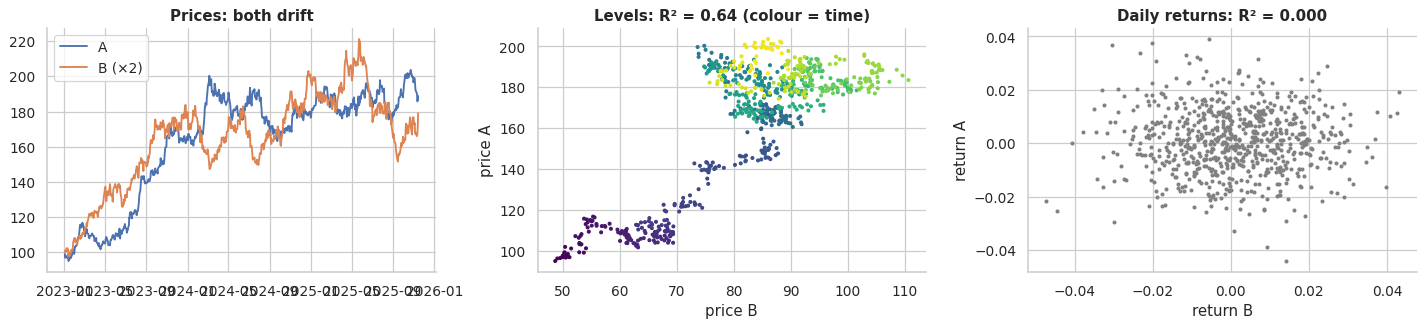

In [7]:
from statsmodels.stats.stattools import durbin_watson
lvl = smf.ols("A ~ B", prices).fit(); ret = np.log(prices).diff().dropna(); rr = smf.ols("A ~ B", ret).fit()
print(f"LEVELS : R² = {lvl.rsquared:.3f}, t = {lvl.tvalues['B']:.1f}, p = {lvl.pvalues['B']:.1e}, Durbin–Watson = {durbin_watson(lvl.resid):.3f}")
print(f"RETURNS: R² = {rr.rsquared:.4f}, t = {rr.tvalues['B']:.2f}, p = {rr.pvalues['B']:.3f}, Durbin–Watson = {durbin_watson(rr.resid):.3f}\n")
for name, s in [("price A", prices.A), ("price B", prices.B), ("return A", ret.A), ("return B", ret.B)]: print(f"ADF {name:9s}: p = {adfuller(s)[1]:.4f}")
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
axes[0].plot(prices.A, color=C[0], label="A"); axes[0].plot(prices.B * 2, color=C[1], label="B (×2)"); axes[0].set_title("Prices: both drift"); axes[0].legend()
axes[1].scatter(prices.B, prices.A, s=5, c=np.arange(n), cmap="viridis"); axes[1].set(title=f"Levels: R² = {lvl.rsquared:.2f} (colour = time)", xlabel="price B", ylabel="price A")
axes[2].scatter(ret.B, ret.A, s=5, color="grey"); axes[2].set(title=f"Daily returns: R² = {rr.rsquared:.3f}", xlabel="return B", ylabel="return A"); plt.tight_layout(); plt.show()

**Interpretation.** In levels the regression looks spectacular — but the Durbin–Watson statistic is close to **0** (for independent residuals it would be ≈ 2): the residuals are almost perfectly autocorrelated, so the classical t-statistic is meaningless. The ADF tests cannot reject a unit root for either price series (large p-values), while the **returns** are clearly stationary (p ≈ 0). Regressing returns on returns, nothing remains: $R^2\approx0$ and an insignificant slope — correctly so, because the two series were simulated **independently**.

**For the analyst:** both prices are random walks with drift; any two such series look related over a given window because each wanders persistently. In the scatterplot, colour reveals the trick: the "relationship" is just time passing. A hedge built on this regression would fail. Relationships between financial series must be studied in **returns** — or, if there is a theoretical reason for a long-run link between levels, with cointegration methods.

### ✍️ Exercise 13.4 — *SARIMA forecasting against a benchmark*: Next year's electricity demand (Energy utility)

A utility has 13 years of monthly electricity demand (GWh). Planning needs a 24-month forecast with uncertainty bands.

**Tasks**
1. Hold out the last 24 months. Plot the training series; describe trend and seasonality.
2. Fit two candidates on the training data — SARIMA(0,1,1)(0,1,1)₁₂ and SARIMA(1,0,0)(0,1,1)₁₂ with drift (`trend="c"`) — and compare their AIC. Check the better model's residuals (Ljung–Box).
3. Forecast 24 months. Compare MAE and MAPE on the hold-out with the **seasonal naive** benchmark. Compute the MASE.
4. How many of the 24 true values fall inside the 95 % prediction interval?

In [8]:
g = np.random.default_rng(1304)
idx = pd.date_range("2012-01-01", periods=156, freq="MS"); t = np.arange(156)
e = np.zeros(156)
for i in range(1, 156): e[i] = .6 * e[i - 1] + g.normal(0, 18)
demand = pd.Series(1500 + 1.8 * t + 120 * np.cos(2 * np.pi * (idx.month - 1) / 12) + 35 * np.cos(4 * np.pi * (idx.month - 7) / 12) + e, index=idx, name="demand_gwh").round(0)
demand.tail(3)

2024-10-01    1782.0
2024-11-01    1868.0
2024-12-01    1931.0
Freq: MS, Name: demand_gwh, dtype: float64

AIC: airline model 1085.7   |   AR(1) + seasonal MA + drift 1076.8
Ljung–Box p-value (lag 24) of the better model's residuals: 0.46
SARIMA         : MAE =  24.6 GWh, MAPE = 1.40%, MASE = 0.77
seasonal naive : MAE =  46.1 GWh, MAPE = 2.58%, MASE = 1.45
23 of 24 true values inside the 95 % prediction interval


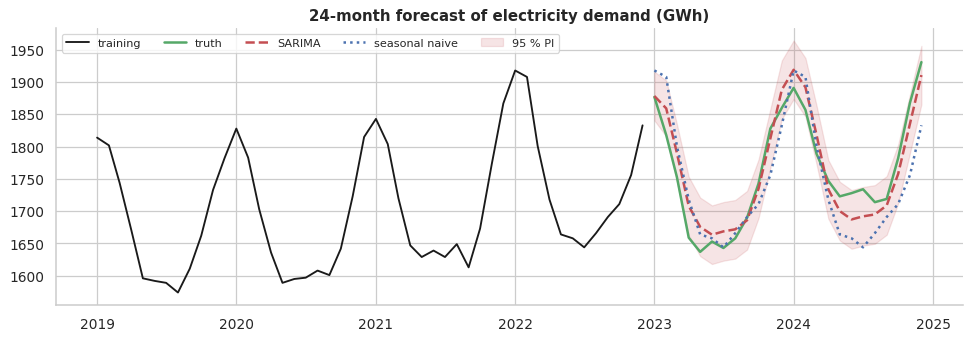

In [9]:
train, test = demand.iloc[:-24], demand.iloc[-24:]
m1 = SARIMAX(train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
m2 = SARIMAX(train, order=(1, 0, 0), seasonal_order=(0, 1, 1, 12), trend="c").fit(disp=False)
print(f"AIC: airline model {m1.aic:.1f}   |   AR(1) + seasonal MA + drift {m2.aic:.1f}")
best = m2 if m2.aic < m1.aic else m1
print(f"Ljung–Box p-value (lag 24) of the better model's residuals: {sm.stats.acorr_ljungbox(best.resid.iloc[13:], lags=[24]).lb_pvalue.iloc[0]:.2f}")
fc = best.get_forecast(24).summary_frame(alpha=.05)
snaive = pd.Series(np.tile(train.iloc[-12:].values, 2), index=test.index)
scale = np.abs(train.values[12:] - train.values[:-12]).mean()                            # in-sample MAE of the seasonal naive forecast
for name, f in [("SARIMA", fc["mean"]), ("seasonal naive", snaive)]:
    err = test - f; print(f"{name:15s}: MAE = {np.abs(err).mean():5.1f} GWh, MAPE = {np.abs(err / test).mean():.2%}, MASE = {np.abs(err).mean() / scale:.2f}")
inside = ((test >= fc.mean_ci_lower) & (test <= fc.mean_ci_upper)).sum(); print(f"{inside} of 24 true values inside the 95 % prediction interval")
fig, ax = plt.subplots(figsize=(13, 4)); ax.plot(train.loc["2019":], color="k", label="training"); ax.plot(test, color=C[2], lw=2, label="truth"); ax.plot(fc["mean"], color=C[3], ls="--", lw=2, label="SARIMA"); ax.plot(snaive, color=C[0], ls=":", lw=2, label="seasonal naive")
ax.fill_between(fc.index, fc.mean_ci_lower, fc.mean_ci_upper, color=C[3], alpha=.15, label="95 % PI"); ax.legend(ncol=5, fontsize=9); ax.set_title("24-month forecast of electricity demand (GWh)"); plt.show()

**Interpretation.** The series has a steady upward trend and a strong yearly pattern (winter peak, a smaller summer bump). The model with an AR(1) term, seasonal MA term and drift wins on AIC — consistent with how the data were generated (autocorrelated deviations around a linear trend) — and its residuals pass the Ljung–Box test.

On the hold-out the SARIMA forecast is clearly better than the seasonal naive benchmark (compare MAE and MASE): the naive forecast simply repeats last year and therefore misses the **trend** — it is systematically too low, and increasingly so in the second year. The MASE of the SARIMA model is well below 1. The 95 % prediction interval covers (nearly) all 24 true values, as it should.

**Lesson:** a forecast without a benchmark is unjudgeable (a MAPE of 1.4 % only becomes meaningful next to the 2.6 % of the trivial method), and a forecast without an interval is unusable for capacity planning.

### ✍️ Exercise 13.5 — *Rolling-origin evaluation*: Is Holt–Winters worth it? (Retail demand planning)

A retailer forecasts monthly sales 12 months ahead. Candidates: **Holt–Winters** exponential smoothing (additive trend, multiplicative seasonality) and the **seasonal naive** method. One train/test split could be luck — evaluate with a rolling origin.

**Tasks**
1. Starting with 72 months of training data, move the origin forward in steps of 3 months as long as 12 future months remain. At each origin fit Holt–Winters, forecast 12 months, and store the absolute percentage errors of both methods **by horizon**.
2. Plot the MAPE against the forecast horizon for both methods.
3. Report the overall MAPE. By how much does Holt–Winters beat the benchmark — and does accuracy decay with the horizon?

In [10]:
g = np.random.default_rng(1305)
idx = pd.date_range("2014-01-01", periods=132, freq="MS"); t = np.arange(132)
fac = np.array([.82, .80, .92, .97, 1.0, .98, .95, .93, 1.0, 1.05, 1.22, 1.55])                # Christmas business
sales = pd.Series(200 * 1.05 ** (t / 12) * fac[idx.month - 1] * g.lognormal(0, .05, 132), index=idx, name="sales_k").round(1)
sales.tail(3)

2024-10-01    366.5
2024-11-01    442.7
2024-12-01    535.8
Freq: MS, Name: sales_k, dtype: float64

17 forecast origins;  overall MAPE:
Holt–Winters      4.69
seasonal naive    7.41
dtype: float64


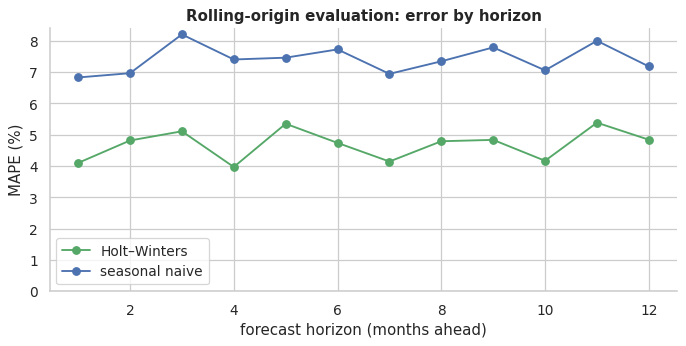

In [11]:
H = 12; ape = {"Holt–Winters": [], "seasonal naive": []}
for origin in range(72, len(sales) - H + 1, 3):
    train, future = sales.iloc[:origin], sales.iloc[origin:origin + H]
    hw = ExponentialSmoothing(train, trend="add", seasonal="mul", seasonal_periods=12).fit().forecast(H)
    ape["Holt–Winters"].append(np.abs(hw.values / future.values - 1)); ape["seasonal naive"].append(np.abs(train.iloc[-12:].values / future.values - 1))
mape = pd.DataFrame({k: np.mean(v, axis=0) for k, v in ape.items()}, index=range(1, H + 1)) * 100
print(f"{len(ape['Holt–Winters'])} forecast origins;  overall MAPE:"); print(mape.mean().round(2))
ax = mape.plot(figsize=(9, 3.8), marker="o", color=[C[2], C[0]]); ax.set(xlabel="forecast horizon (months ahead)", ylabel="MAPE (%)", title="Rolling-origin evaluation: error by horizon", ylim=(0, None)); plt.show()

**Interpretation.** Averaged over all origins and horizons, Holt–Winters has a clearly lower MAPE than the seasonal naive forecast. The naive method carries a built-in bias: it repeats last year's level and ignores ≈ 5 % annual growth, so its error sits near 7–8 % at every horizon. Holt–Winters models level, trend *and* seasonality; its error stays close to the irreducible noise (≈ 4–5 %, from the 5 % log-normal noise) across the whole year, because trend and seasonal pattern are very stable in these data. In less regular series the error typically grows with the horizon — which is exactly what this kind of plot is designed to reveal.

**Lesson:** rolling-origin evaluation gives an *error profile by horizon* from many forecast origins instead of one lucky or unlucky split — this is the honest basis for choosing a forecasting method and for telling planners how much safety stock each horizon needs.